In [ ]:
%%capture
!pip install pandas
!pip install numpy

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CSV/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

9800

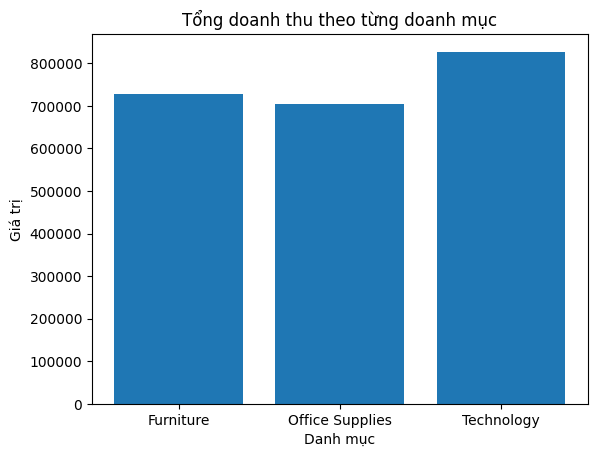

In [ ]:
query = """
        SELECT Category, SUM(Sales)
        FROM sales
        GROUP BY Category
        """
res = pd.read_sql(query, conn)
res

plt.bar(res['Category'], res['SUM(Sales)'])
plt.title("Tổng doanh thu theo từng doanh mục")
plt.xlabel("Danh mục")
plt.ylabel("Giá trị")
plt.savefig("category_chart.png")
plt.show()

In [ ]:
query2 ="""
        SELECT Category, COUNT(*)
        FROM sales
        GROUP BY Category
        """
res2 = pd.read_sql(query2, conn)
res2

,Category,COUNT(*)
0,Furniture,2078
1,Office Supplies,5909
2,Technology,1813


In [ ]:
mean_sales = """
            SELECT Category, AVG(Sales)
            FROM sales
            GROUP BY Category
            ORDER BY AVG(Sales) DESC
            """
res3 = pd.read_sql(mean_sales, conn)
res3

,Category,AVG(Sales)
0,Technology,456.401474
1,Furniture,350.653790
2,Office Supplies,119.381001


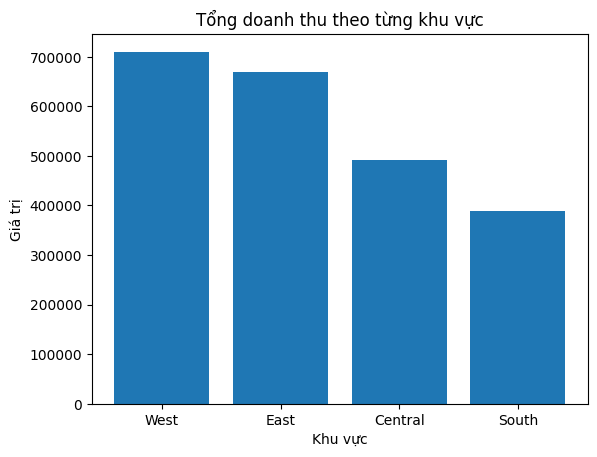

In [ ]:
region_sales = """
            SELECT Region, SUM(Sales)
            FROM sales
            GROUP BY Region
            ORDER BY SUM(Sales) DESC
            """
res4 = pd.read_sql(region_sales, conn)
res4

plt.bar(res4['Region'], res4['SUM(Sales)'])
plt.title("Tổng doanh thu theo từng khu vực")
plt.xlabel("Khu vực")
plt.ylabel("Giá trị")
plt.savefig("region_chart.png")
plt.show()

In [ ]:
region_sales_gap = res4.iloc[0,1] - res4.iloc[3,1]
print(region_sales_gap)

321068.22549999994


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst = True)
df['Year'] = df['Order Date'].dt.year
df.to_sql('sales', conn, index=False, if_exists='replace')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016


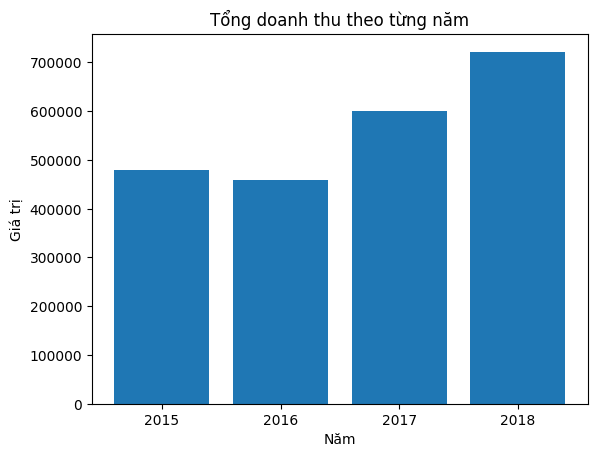

In [ ]:
year_sales = """
            SELECT Year, SUM(Sales), COUNT(*), AVG(Sales), MIN(Sales), MAX(Sales)
            FROM sales
            GROUP BY Year
            ORDER BY Year DESC
            """
res5 = pd.read_sql(year_sales, conn)
res5

plt.bar(res5['Year'], res5['SUM(Sales)'])
plt.xticks(res5['Year'])
plt.title("Tổng doanh thu theo từng năm")
plt.xlabel("Năm")
plt.ylabel("Giá trị")
plt.savefig("year_chart.png")
plt.show()